In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print(len(train_dataset))
print(len(test_dataset))

100%|██████████| 26.4M/26.4M [00:01<00:00, 22.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 338kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.21MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.07MB/s]

60000
10000


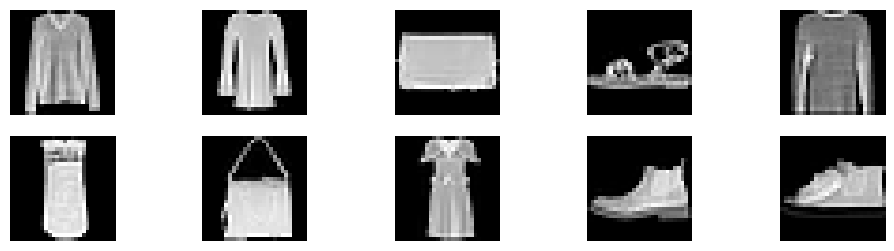

In [4]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12,3))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

In [8]:
def show_reconstruction(model, loader):
    
    model.eval()

    with torch.no_grad():
        images, _ = next(iter(loader))

        images = images.to(device)

        outputs = model(images)

    images = images.cpu()
    outputs = outputs.cpu()

    plt.figure(figsize=(12,4))

    for i in range(6):

        plt.subplot(2,6,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.axis("off")

        plt.subplot(2,6,i+7)
        plt.imshow(outputs[i].squeeze(), cmap="gray")
        plt.axis("off")

    plt.show()

In [9]:
def train_autoencoder(latent_dim):

    class Autoencoder(nn.Module):

        def __init__(self):

            super().__init__()

            self.encoder = nn.Sequential(

                nn.Flatten(),

                nn.Linear(784,256),
                nn.ReLU(),

                nn.Linear(256,128),
                nn.ReLU(),

                nn.Linear(128,latent_dim)

            )

            self.decoder = nn.Sequential(

                nn.Linear(latent_dim,128),
                nn.ReLU(),

                nn.Linear(128,256),
                nn.ReLU(),

                nn.Linear(256,784),
                nn.Sigmoid()

            )

        def forward(self,x):

            z = self.encoder(x)

            x = self.decoder(z)

            return x.view(-1,1,28,28)

    model = Autoencoder().to(device)

    criterion = nn.MSELoss()

    optimizer = optim.Adam(model.parameters(),lr=0.001)

    epochs = 10

    losses=[]

    for epoch in range(epochs):

        running_loss=0

        model.train()

        for images,_ in train_loader:

            images=images.to(device)

            outputs=model(images)

            loss=criterion(outputs,images)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss+=loss.item()

        epoch_loss=running_loss/len(train_loader)

        losses.append(epoch_loss)

        print(f"Latent {latent_dim} Epoch {epoch+1}/{epochs} Loss {epoch_loss:.5f}")

    return model,losses

In [10]:
model2, loss2 = train_autoencoder(2)

Latent 2 Epoch 1/10 Loss 0.04089
Latent 2 Epoch 2/10 Loss 0.03024
Latent 2 Epoch 3/10 Loss 0.02892
Latent 2 Epoch 4/10 Loss 0.02816
Latent 2 Epoch 5/10 Loss 0.02771
Latent 2 Epoch 6/10 Loss 0.02735
Latent 2 Epoch 7/10 Loss 0.02710
Latent 2 Epoch 8/10 Loss 0.02688
Latent 2 Epoch 9/10 Loss 0.02656
Latent 2 Epoch 10/10 Loss 0.02637


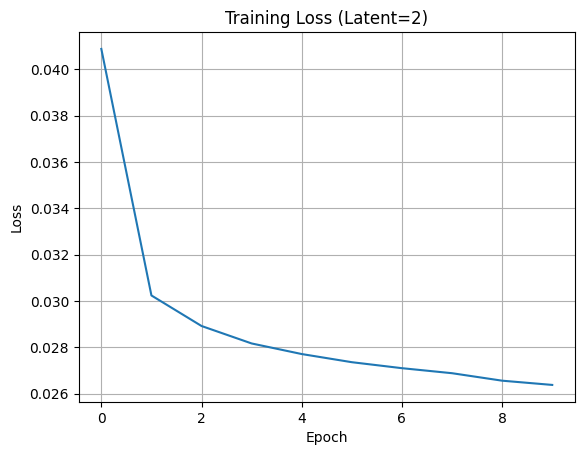

In [11]:
plt.plot(loss2)

plt.title("Training Loss (Latent=2)")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

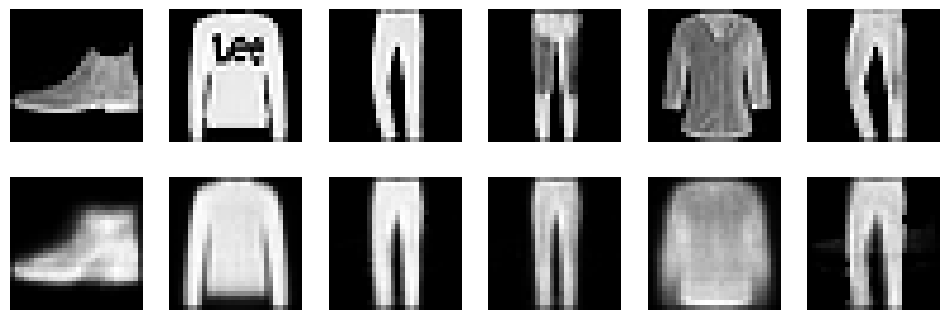

In [12]:
show_reconstruction(model2,test_loader)

In [13]:
torch.save(model2.state_dict(),"autoencoder_latent2.pth")

print("Model berhasil disimpan")

Model berhasil disimpan


In [14]:
model8, loss8 = train_autoencoder(8)

Latent 8 Epoch 1/10 Loss 0.03613
Latent 8 Epoch 2/10 Loss 0.02105
Latent 8 Epoch 3/10 Loss 0.01826
Latent 8 Epoch 4/10 Loss 0.01687
Latent 8 Epoch 5/10 Loss 0.01612
Latent 8 Epoch 6/10 Loss 0.01560
Latent 8 Epoch 7/10 Loss 0.01523
Latent 8 Epoch 8/10 Loss 0.01493
Latent 8 Epoch 9/10 Loss 0.01468
Latent 8 Epoch 10/10 Loss 0.01449


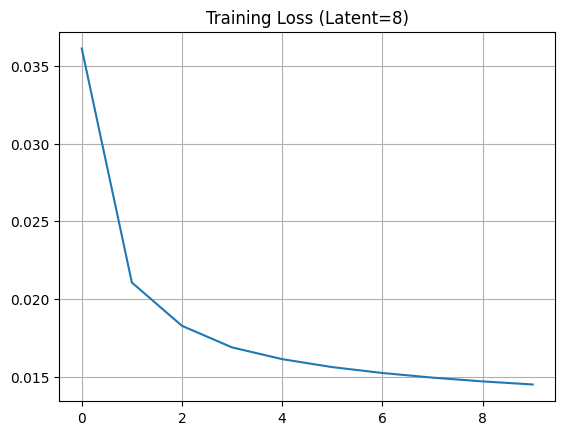

In [16]:
plt.plot(loss8)

plt.title("Training Loss (Latent=8)")

plt.grid()

plt.show()

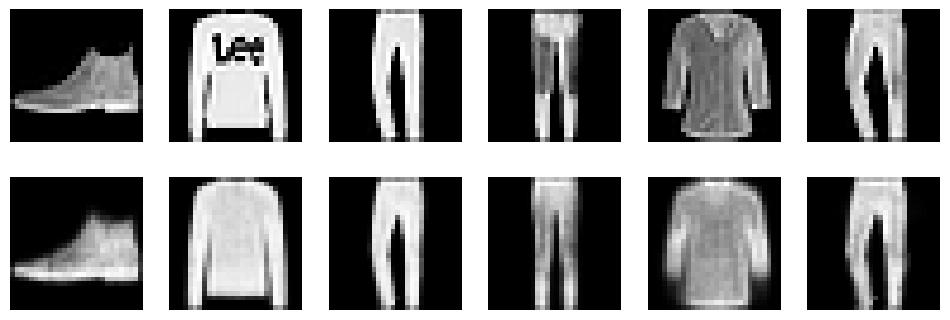

In [17]:
show_reconstruction(model8,test_loader)

In [ ]:
torch.save(model8.state_dict(),"autoencoder_latent8.pth")

In [ ]:
model32, loss32 = train_autoencoder(32)

Latent 32 Epoch 1/10 Loss 0.03797
Latent 32 Epoch 2/10 Loss 0.02011
Latent 32 Epoch 3/10 Loss 0.01731


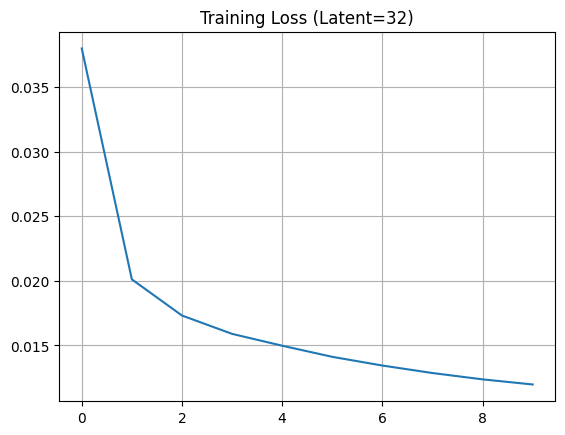

In [46]:
plt.plot(loss32)

plt.title("Training Loss (Latent=32)")

plt.grid()

plt.show()

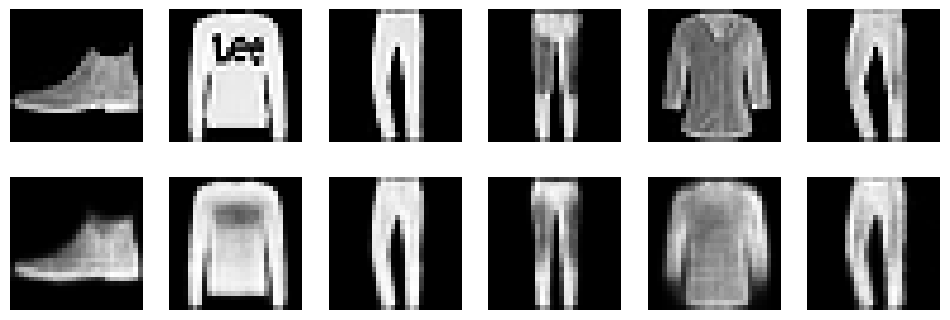

In [47]:
show_reconstruction(model32,test_loader)

In [51]:
torch.save(model32.state_dict(),"autoencoder_latent32.pth")

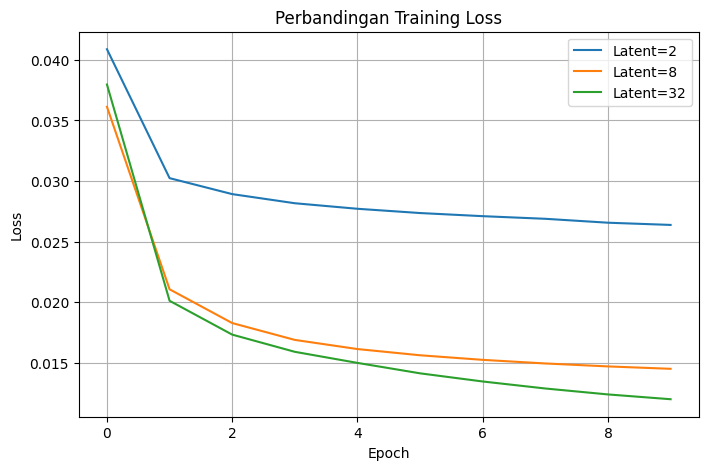

In [53]:
plt.figure(figsize=(8,5))

plt.plot(loss2,label="Latent=2")

plt.plot(loss8,label="Latent=8")

plt.plot(loss32,label="Latent=32")

plt.legend()

plt.grid()

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Perbandingan Training Loss")

plt.show()

In [54]:
torch.save(model32.encoder.state_dict(),"encoder_fashion_mnist.pth")

torch.save(model32.decoder.state_dict(),"decoder_fashion_mnist.pth")

print("Encoder dan Decoder berhasil disimpan.")

Encoder dan Decoder berhasil disimpan.
